## Exploratory Data Analysis

Roles to explore:

In [1]:
# importing liberaries:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from datasets import load_dataset
import ast

# loading dataset
dataset = load_dataset('lukebarousse/data_jobs')

# turning dataset into a dataframe
df = dataset['train'].to_pandas()

# cleaning dataframe
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\DELL\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filter down for US data analyst roles

In [2]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

Text(0, 0.5, '')

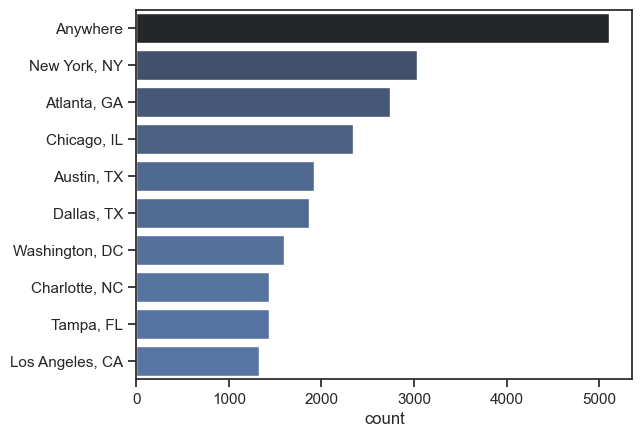

In [19]:
df_location = df_da_us['job_location'].value_counts().head(10).to_frame()
df_location
sns.barplot(data=df_location, x='count', y='job_location', hue='count', palette='dark:b_r',legend=False)
sns.set_theme(style='ticks')
plt.ylabel('')

In [46]:
df_remote = df_da_us['job_work_from_home'].value_counts()
no_degree = df_da_us['job_no_degree_mention'].value_counts()
health_insurance = df_da_us['job_health_insurance'].value_counts()

Text(0.5, 1.0, 'Health Insurance Offered')

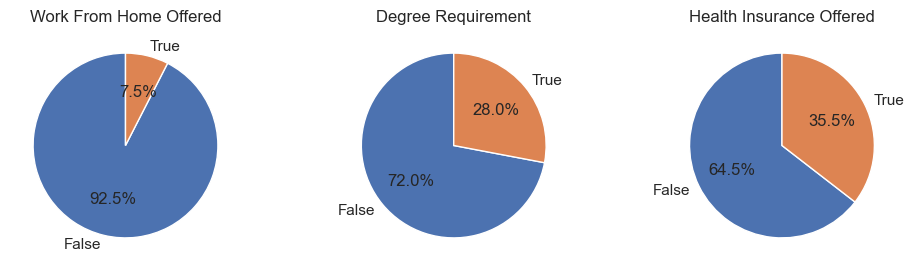

In [55]:
fig, ax = plt.subplots(1, 3,figsize=(12,3))

plot1 = df_remote.plot(kind='pie', ax=ax[0],startangle=90, autopct='%1.1f%%')
ax[0].set_title('Work From Home Offered') 
plot1 = no_degree.plot(kind='pie', ax=ax[1],startangle=90, autopct='%1.1f%%')
ax[1].set_title('Degree Requirement') 
plot1 = health_insurance.plot(kind='pie', ax=ax[2],startangle=90, autopct='%1.1f%%')
ax[2].set_title('Health Insurance Offered') 